# AEV-PLIG Results Analysis
Multi-model accuracy · ensemble agreement · uncertainty calibration · ranking · outliers

In [2]:
import re


import numpy as np
import polars as pl
import uncertainty_toolbox as uct
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.special import erf
from scipy.stats import kendalltau as scipy_kendalltau

from aev_plig import results

In [50]:
PREDICTIONS_DIR      = "../output/predictions"
# Stem of the parquet file produced by scripts/predict.py, e.g.:
# "pdbbind_U_bindingnet_U_bindingdb_ligsim90_fep_benchmark_predictions"
PREDICTION_FILE_NAME = "pdbbind_U_bindingnet_U_bindingdb_ligsim90_fep_benchmark_predictions"
TRUTH_COL            = "pK"
PRED_COL             = "preds"
UID_COL              = "unique_id"
TOP_N_OUTLIERS       = 20
MIN_TARGET_SAMPLES   = 0
FIG_DIR              = None   # set to a Path to auto-save HTML figures

In [5]:
df = results.load_all_predictions(PREDICTIONS_DIR, prediction_file_name=PREDICTION_FILE_NAME)

# Auto-detect ensemble member columns (preds_0, preds_1, ...)
pred_member_cols = sorted(
    [c for c in df.columns if re.fullmatch(r"preds_\d+", c)],
    key=lambda c: int(c.split("_")[1]),
)
n_models = len(pred_member_cols)

# Detect Bayesian output (var_0 ... var_N present)
var_member_cols = sorted(
    [c for c in df.columns if re.fullmatch(r"var_\d+", c)],
    key=lambda c: int(c.split("_")[1]),
)
is_bayesian_output = bool(var_member_cols)

print(
    f"Rows: {df.height:,} | ensemble members: {n_models} "
    f"| Bayesian output: {is_bayesian_output}"
)

# Epistemic std = disagreement across the N ensemble checkpoints
df = df.with_columns(
    (
        pl.concat_list([pl.col(c) for c in pred_member_cols]).list.std()
        if n_models > 1
        else pl.lit(0.0)
    ).alias("epistemic_std")
)

# Aleatoric std = sqrt(mean aleatoric variance from Bayesian head), pK units
if is_bayesian_output:
    df = df.with_columns(pl.col("var").sqrt().alias("aleatoric_std"))

# Residual (signed: predicted - true)
if TRUTH_COL in df.columns:
    df = df.with_columns((pl.col(PRED_COL) - pl.col(TRUTH_COL)).alias("residual"))

df.head(3)

Rows: 1,385 | ensemble members: 10 | Bayesian output: False


graph_id,unique_id,pK,sdf_file,pdb_file,preds_0,preds_1,preds_2,preds_3,preds_4,preds_5,preds_6,preds_7,preds_8,preds_9,preds,model_name,model_instance,epistemic_std,residual
i64,str,f64,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str,f32,f64
0,"""3ao4""",2.07,"""data/pdbbind/refined-set/3ao4/…","""data/pdbbind/refined-set/3ao4/…",2.80261,3.035815,3.54688,3.06979,3.041111,3.576015,2.879658,3.396887,4.026591,3.554191,3.292955,"""GATv2Net""","""model_GATv2Net_ligsim90_fep_be…",0.387653,1.222955
1,"""3gv9""",2.12,"""data/pdbbind/refined-set/3gv9/…","""data/pdbbind/refined-set/3gv9/…",3.53707,3.362533,3.671967,3.411681,3.161837,3.783965,3.313196,3.169116,3.937509,3.147741,3.449661,"""GATv2Net""","""model_GATv2Net_ligsim90_fep_be…",0.27632,1.329661
2,"""1uto""",2.27,"""data/pdbbind/refined-set/1uto/…","""data/pdbbind/refined-set/1uto/…",3.420526,2.924118,3.026042,2.728463,3.527043,2.933231,2.642881,2.261467,2.81685,3.27312,2.955374,"""GATv2Net""","""model_GATv2Net_ligsim90_fep_be…",0.380121,0.685374


## §1 Data Overview

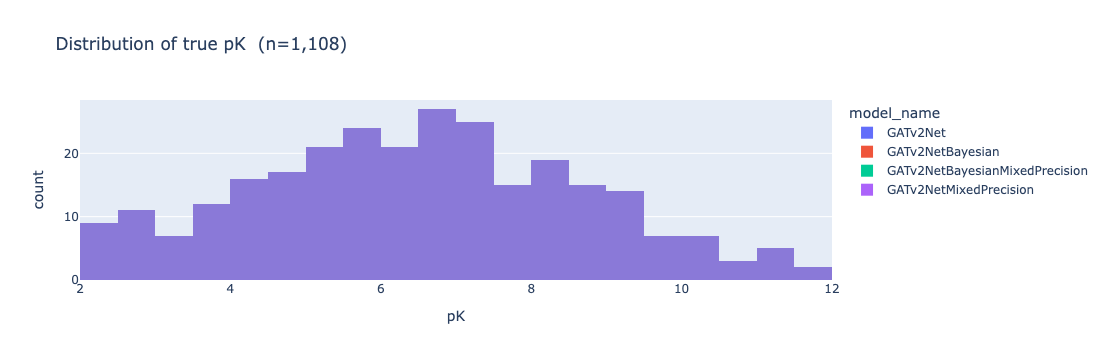

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ pK       │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 1108.0   │
│ null_count ┆ 0.0      │
│ mean       ┆ 6.460217 │
│ std        ┆ 2.185744 │
│ min        ┆ 2.07     │
│ 25%        ┆ 4.89     │
│ 50%        ┆ 6.5      │
│ 75%        ┆ 8.02     │
│ max        ┆ 11.82    │
└────────────┴──────────┘


In [6]:
clean = df.filter(pl.col(TRUTH_COL).is_not_null())
color_col = "model_name" if "model_name" in clean.columns else None
fig = px.histogram(
    clean.to_dict(as_series=False),
    x=TRUTH_COL,
    nbins=40,
    color=color_col,
    barmode="overlay",
    opacity=0.7,
    title=f"Distribution of true {TRUTH_COL}  (n={clean.height:,})",
)
fig.show()
print(clean.select(TRUTH_COL).describe())

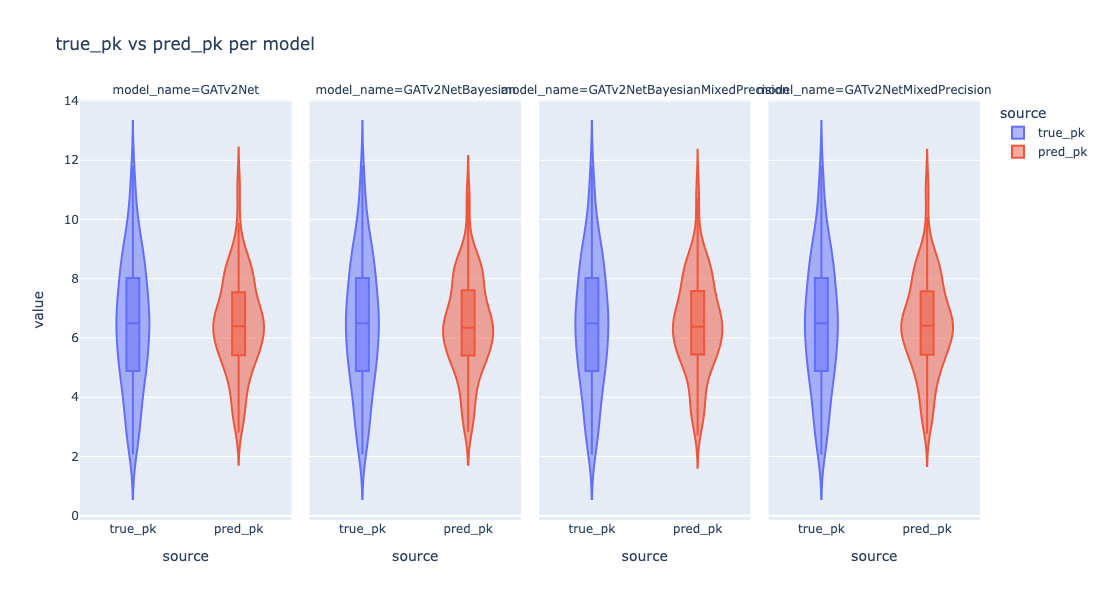

In [7]:
value_cols = [TRUTH_COL, PRED_COL]

long = (
    df.select(["model_name"] + value_cols)
      .drop_nulls()
      .unpivot(
          on=value_cols,
          index="model_name",
          variable_name="source",
          value_name="value",
      )
      .with_columns(
          pl.when(pl.col("source") == TRUTH_COL)
            .then(pl.lit("true_pk"))
            .otherwise(pl.lit("pred_pk"))
            .alias("source")
      )
)

fig = px.violin(
    long.to_dict(as_series=False),
    x="source",
    y="value",
    color="source",
    facet_col="model_name",
    box=True,
    points=False,
    title="true_pk vs pred_pk per model",
)

fig.update_layout(width=1200, height=600)
fig.show()


## §2 Ensemble Member Metrics
RMSE, Pearson R, and Kendall τ for every ensemble member and the ensemble average,
grouped by `model_instance` when multiple model runs are loaded.

model_instance,model_col,RMSE,Pearson R,Kendall τ
str,str,f64,f64,f64
"""GATv2NetBayesianMixedPrecision…","""preds""",1.050558,0.888063,0.720141
"""GATv2NetBayesianMixedPrecision…","""preds_0""",1.097717,0.871729,0.696593
"""GATv2NetBayesianMixedPrecision…","""preds_1""",1.076866,0.878403,0.712689
"""GATv2NetBayesianMixedPrecision…","""preds_2""",1.13808,0.860334,0.685314
"""GATv2NetBayesianMixedPrecision…","""preds_3""",1.087919,0.870979,0.692648
…,…,…,…,…
"""model_GATv2Net_ligsim90_fep_be…","""preds_5""",1.10669,0.872198,0.698144
"""model_GATv2Net_ligsim90_fep_be…","""preds_6""",1.132149,0.863569,0.68835
"""model_GATv2Net_ligsim90_fep_be…","""preds_7""",1.059538,0.88142,0.709142


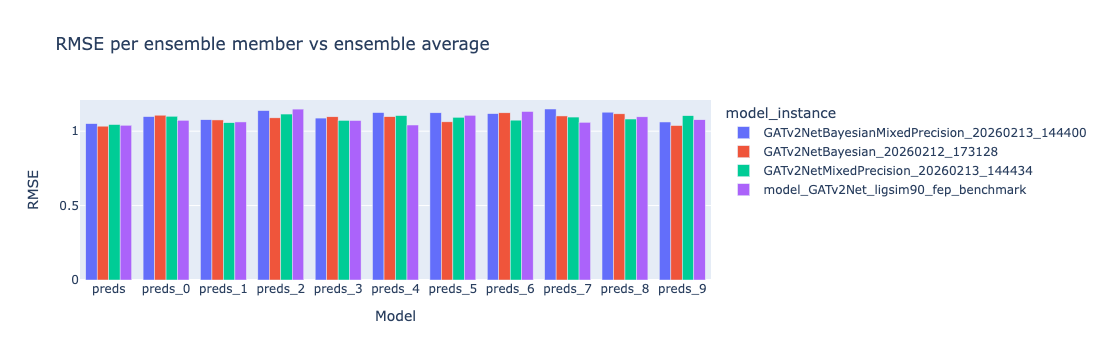

In [8]:
id_cols = [TRUTH_COL] + (["model_instance"] if "model_instance" in df.columns else [])
long = (
    df.select(id_cols + pred_member_cols + [PRED_COL])
    .drop_nulls()
    .unpivot(
        on=pred_member_cols + [PRED_COL],
        index=id_cols,
        variable_name="model_col",
        value_name="pred",
    )
)

group_keys = ["model_instance", "model_col"] if "model_instance" in long.columns else ["model_col"]

metrics_df = (
    long.group_by(group_keys, maintain_order=True)
    .agg(
        ((pl.col("pred") - pl.col(TRUTH_COL))
            .pow(2)
            .mean()
            .sqrt()
        ).alias("RMSE"),

        pl.corr("pred", TRUTH_COL).alias("Pearson R"),

        pl.map_groups(
            ["pred", TRUTH_COL],
            lambda s: scipy_kendalltau(
                s[0].to_numpy(),
                s[1].to_numpy()
            ).statistic,
            return_dtype=pl.Float64,
            returns_scalar=True,   # ← THIS is what you're missing
        ).alias("Kendall τ"),
    )
    .sort(group_keys)
)

display(metrics_df)

fig = px.bar(
    metrics_df.to_dict(as_series=False),
    x="model_col",
    y="RMSE",
    color="model_instance" if "model_instance" in metrics_df.columns else None,
    barmode="group",
    title="RMSE per ensemble member vs ensemble average",
    labels={"model_col": "Model"},
)
fig.show()

## §3 Predicted vs True
Colour and error bars show epistemic std (ensemble disagreement).

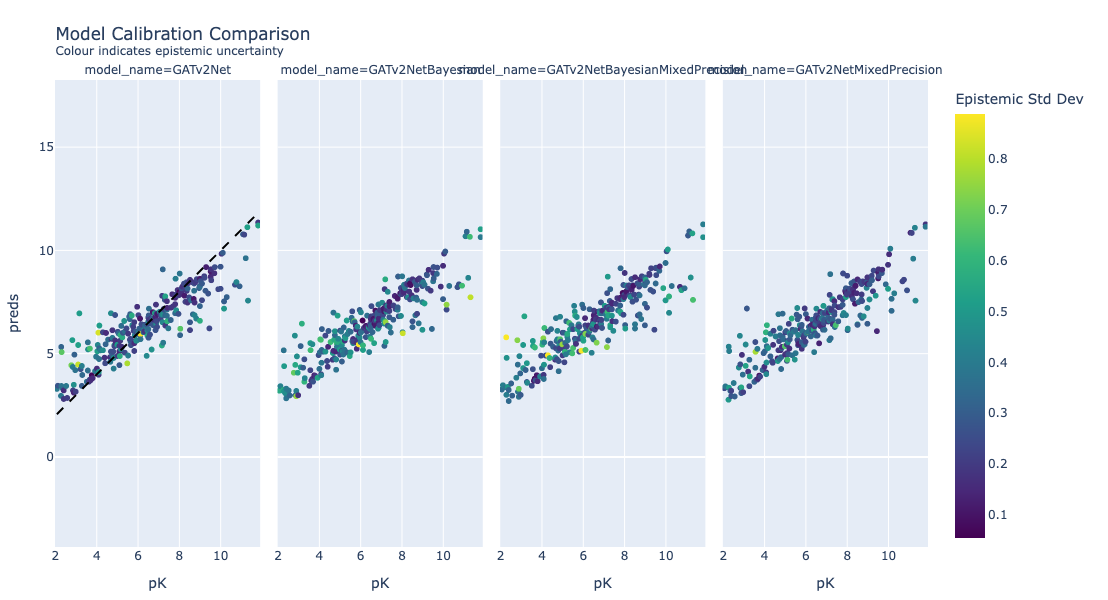

In [26]:
def plot_pred_vs_true(
    df,
    truth_col,
    pred_col,
    uid_col,
    std_col="epistemic_std",
    facet_col="model_name",
    title=None,
    subtitle=None,
    height=600,
):
    import plotly.express as px
    import plotly.graph_objects as go

    scatter_cols = [truth_col, pred_col, uid_col, std_col]
    if facet_col in df.columns:
        scatter_cols.append(facet_col)

    plot_df = df.select(scatter_cols).drop_nulls()

    x_min = float(plot_df[truth_col].min())
    x_max = float(plot_df[truth_col].max())
    x_range = [x_min, x_max]

    # Custom title handling
    if title is None:
        title = f"Predicted vs True"
    if subtitle:
        title = f"{title}<br><sup>{subtitle}</sup>"

    fig = px.scatter(
        plot_df.to_dict(as_series=False),
        x=truth_col,
        y=pred_col,
        color=std_col,
        color_continuous_scale="Viridis",
        facet_col=facet_col if facet_col in plot_df.columns else None,
        hover_data={
            uid_col: True,
            truth_col: ":.4f",
            pred_col: ":.4f",
            std_col: ":.4f",
        },
        title=title,
        height=height,
    )

    # Add y=x reference line correctly across facets
    fig.add_shape(
        type="line",
        x0=x_min,
        y0=x_min,
        x1=x_max,
        y1=x_max,
        line=dict(dash="dash", color="black"),
        xref="x",
        yref="y",
    )

    # Force identical axis ranges (important for comparison)
    fig.update_xaxes(range=x_range, scaleanchor="y")
    fig.update_yaxes(range=x_range)

    fig.update_layout(
        coloraxis_colorbar=dict(title="Epistemic Std Dev"),
        margin=dict(l=40, r=40, t=80, b=40),
    )

    return fig

fig = plot_pred_vs_true(
    df,
    TRUTH_COL,
    PRED_COL,
    UID_COL,
    title="Model Calibration Comparison",
    subtitle="Colour indicates epistemic uncertainty",
)
fig.show()


## §4 Residual Analysis

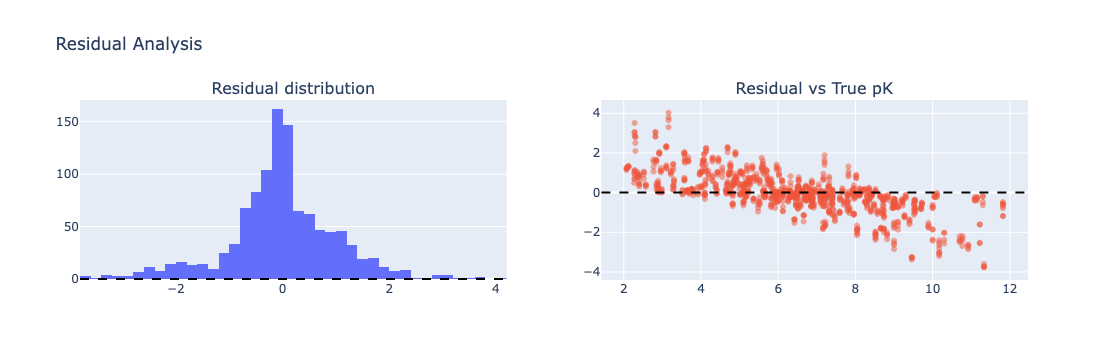

In [10]:
res = df.select([TRUTH_COL, "residual", UID_COL]).drop_nulls()
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Residual distribution", f"Residual vs True {TRUTH_COL}"],
)
fig.add_trace(
    go.Histogram(x=res["residual"].to_numpy(), nbinsx=40, name="Residuals"),
    row=1, col=1,
)
fig.add_trace(
    go.Scatter(
        x=res[TRUTH_COL].to_numpy(), y=res["residual"].to_numpy(),
        mode="markers", text=res[UID_COL].to_list(),
        marker=dict(opacity=0.5), name="Residual",
    ),
    row=1, col=2,
)
fig.add_hline(y=0, line_dash="dash", line_color="black")
fig.update_layout(title="Residual Analysis", showlegend=False)
fig.show()

## §5 Uncertainty Calibration

**Epistemic std** = std dev of the N ensemble checkpoint predictions (`std(preds_0…N)`).
Valid for all model types.

**Aleatoric std** *(Bayesian models only)* = `sqrt(mean(var_0…N))`, where each `var_i`
is the variance from the model’s `logvar_head` (softplus-activated, denormalised to pK²).
This is the model’s self-reported data noise, independent of ensemble disagreement.

Three diagnostics are shown for each uncertainty source:
1. **Scatter** — uncertainty vs |residual|; Pearson R quantifies linear correlation
2. **Reliability diagram** — bin by uncertainty quantile, plot mean |error| per bin; a
   well-calibrated model has a monotonically increasing curve
3. **Sparsification curve** — rank predictions from most to least confident; progressively
   include more uncertain predictions and track RMSE; good calibration shows RMSE rising
   as uncertain predictions are added
4. **Prediction interval coverage** — what fraction of true values fall within ±kσ;
   a Gaussian-calibrated model matches the theoretical erf curve

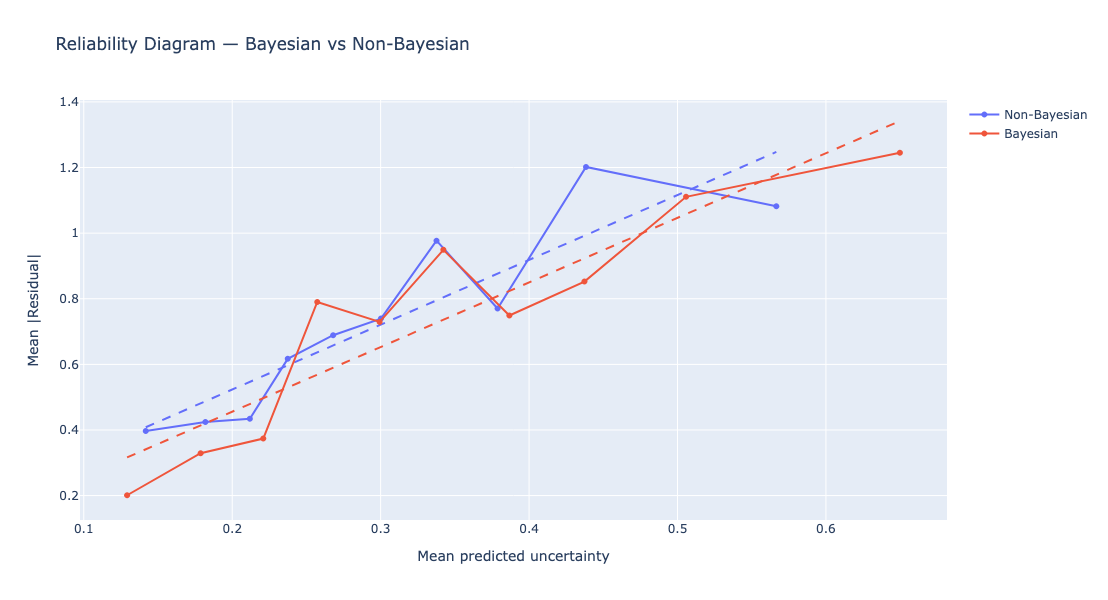

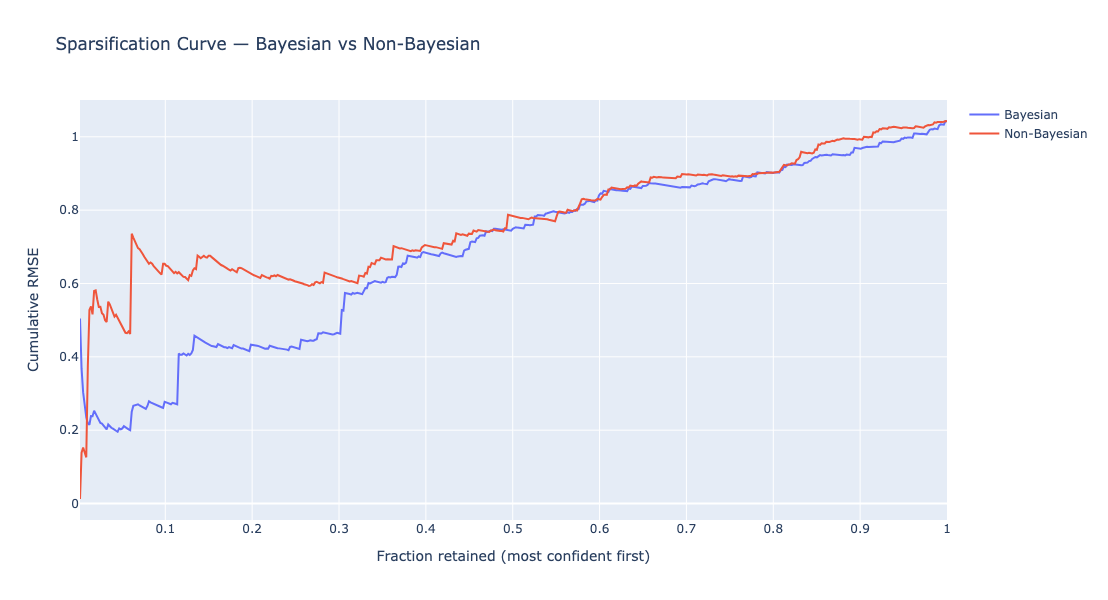

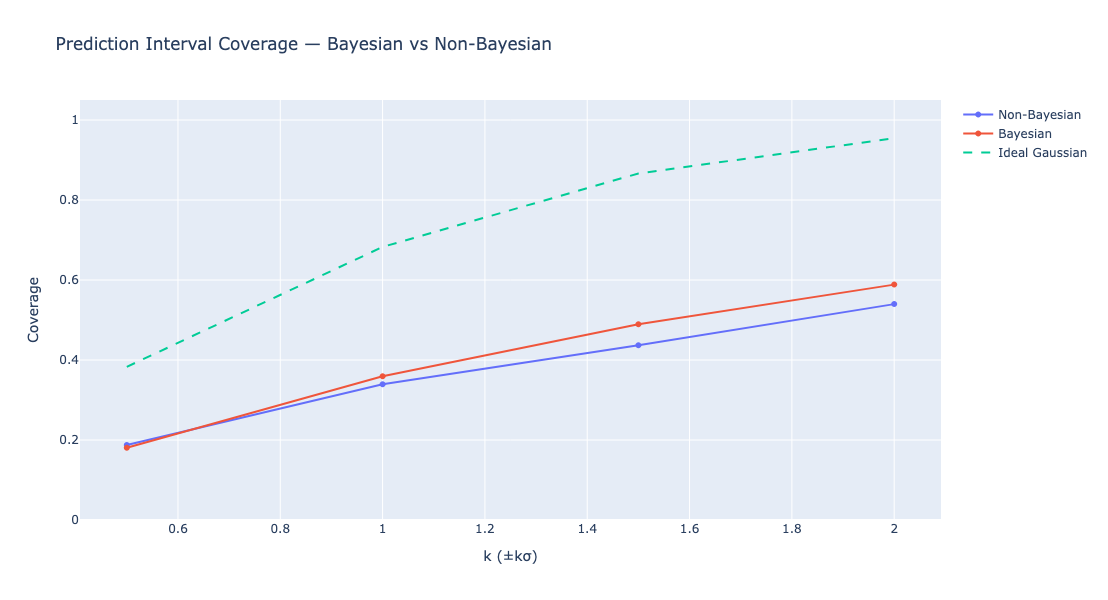

In [11]:
def reliability_diagram(unc: np.ndarray, abs_err: np.ndarray, n_bins: int = 10):
    bin_edges = np.percentile(unc, np.linspace(0, 100, n_bins + 1))
    bin_idx   = np.searchsorted(bin_edges[1:-1], unc)
    counts    = np.bincount(bin_idx, minlength=n_bins).astype(float)
    mean_unc  = np.bincount(bin_idx, weights=unc,     minlength=n_bins) / counts
    mean_err  = np.bincount(bin_idx, weights=abs_err, minlength=n_bins) / counts
    return mean_unc, mean_err


def sparsification_curve(unc: np.ndarray, residuals: np.ndarray):
    order         = np.argsort(unc)
    sq_err_sorted = residuals[order] ** 2
    cum_rmse      = np.sqrt(np.cumsum(sq_err_sorted) / np.arange(1, len(sq_err_sorted) + 1))
    frac_retained = np.arange(1, len(sq_err_sorted) + 1) / len(sq_err_sorted)
    return frac_retained, cum_rmse


def interval_coverage(unc: np.ndarray, residuals: np.ndarray):
    k_vals       = np.array([0.5, 1.0, 1.5, 2.0])
    obs_cov      = (np.abs(residuals)[None, :] <= k_vals[:, None] * unc[None, :]).mean(axis=1)
    expected_cov = erf(k_vals / np.sqrt(2))
    return k_vals, obs_cov, expected_cov


# -------------------------
# Add model type column
# -------------------------

df = df.with_columns(
    pl.when(pl.col("model_name").str.contains("Bayesian"))
      .then(pl.lit("Bayesian"))
      .otherwise(pl.lit("Non-Bayesian"))
      .alias("model_type")
)


# -------------------------
# Reliability diagram
# -------------------------

fig_rel = go.Figure()

model_types = df["model_type"].unique()
colors = px.colors.qualitative.Plotly  # default Plotly palette
color_map = {mt: colors[i % len(colors)] for i, mt in enumerate(model_types)}

for model_type in model_types:
    sub = (
        df.filter(pl.col("model_type") == model_type)
          .select(["epistemic_std", "residual"])
          .drop_nulls()
    )

    unc = sub["epistemic_std"].to_numpy()
    abs_err = np.abs(sub["residual"].to_numpy())

    mu_unc, mu_err = reliability_diagram(unc, abs_err)

    color = color_map[model_type]

    # Binned reliability curve
    fig_rel.add_trace(
        go.Scatter(
            x=mu_unc,
            y=mu_err,
            mode="markers+lines",
            name=f"{model_type}",
            line=dict(color=color),
            marker=dict(color=color),
        )
    )

    # Trendline (same colour, dashed)
    slope, intercept = np.polyfit(mu_unc, mu_err, 1)
    xs = np.linspace(mu_unc.min(), mu_unc.max(), 100)
    ys = slope * xs + intercept

    fig_rel.add_trace(
        go.Scatter(
            x=xs,
            y=ys,
            mode="lines",
            line=dict(color=color, dash="dash"),
            showlegend=False,
        )
    )

fig_rel.update_layout(
    title="Reliability Diagram — Bayesian vs Non-Bayesian",
    xaxis_title="Mean predicted uncertainty",
    yaxis_title="Mean |Residual|",
    width=800,
    height=600,
)

fig_rel.show()


# -------------------------
# Sparsification curve
# -------------------------

fig_sparse = go.Figure()

for model_type in df["model_type"].unique():
    sub = (
        df.filter(pl.col("model_type") == model_type)
          .select(["epistemic_std", "residual"])
          .drop_nulls()
    )

    frac, cum_rmse = sparsification_curve(
        sub["epistemic_std"].to_numpy(),
        sub["residual"].to_numpy(),
    )

    fig_sparse.add_trace(
        go.Scatter(
            x=frac,
            y=cum_rmse,
            mode="lines",
            name=model_type,
        )
    )

fig_sparse.update_layout(
    title="Sparsification Curve — Bayesian vs Non-Bayesian",
    xaxis_title="Fraction retained (most confident first)",
    yaxis_title="Cumulative RMSE",
    width=800,
    height=600,
)

fig_sparse.show()


# -------------------------
# Prediction interval coverage
# -------------------------

fig_cov = go.Figure()

for model_type in df["model_type"].unique():
    sub = (
        df.filter(pl.col("model_type") == model_type)
          .select(["epistemic_std", "residual"])
          .drop_nulls()
    )

    k_vals, obs_cov, expected_cov = interval_coverage(
        sub["epistemic_std"].to_numpy(),
        sub["residual"].to_numpy(),
    )

    fig_cov.add_trace(
        go.Scatter(
            x=k_vals,
            y=obs_cov,
            mode="lines+markers",
            name=model_type,
        )
    )

# Ideal Gaussian reference
fig_cov.add_trace(
    go.Scatter(
        x=k_vals,
        y=expected_cov,
        mode="lines",
        line=dict(dash="dash"),
        name="Ideal Gaussian",
    )
)

fig_cov.update_layout(
    title="Prediction Interval Coverage — Bayesian vs Non-Bayesian",
    xaxis_title="k (±kσ)",
    yaxis_title="Coverage",
    yaxis=dict(range=[0, 1.05]),
    width=800,
    height=600,
)

fig_cov.show()

 (1/n) Calculating accuracy metrics
 (2/n) Calculating average calibration metrics
 (3/n) Calculating adversarial group calibration metrics
  [1/2] for mean absolute calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|███████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  8.17it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|███████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  8.19it/s]
/tmp/ipykernel_4004949/2903143005.py:14: DeprecationWarning:

`trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.



 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.733
  RMSE          1.051
  MDAE          0.463
  MARPD         12.532
  R2            0.769
  Correlation   0.888
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.247
  Mean-absolute Calibration Error       0.219
  Miscalibration Area                   0.221
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.304
     Group Size: 0.56 -- Calibration Error: 0.244
     Group Size: 1.00 -- Calibration Error: 0.219
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.329
     Group Size: 0.56 -- Calibration Error: 0.277
     Group Size: 1.00 -- Calibration Error: 0.247
===============

...

 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.733
  RMSE          1.034
  MDAE          0.516
  MARPD         12.495
  R2            0.776
  Correlation   0.895
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.264
  Mean-absolute Calibration Error       0.232
  Miscalibration Area                   0.234
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.308
     Group Size: 0.56 -- Calibration Error: 0.251
     Group Size: 1.00 -- Calibration Error: 0.232
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.341
     Group Size: 0.56 -- Calibration Error: 0.293
     Group Size: 1.00 -- Calibration Error: 0.264
===============

100%|███████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  8.21it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|███████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  8.15it/s]
/tmp/ipykernel_4004949/2903143005.py:14: DeprecationWarning:

`trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.



 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.735
  RMSE          1.044
  MDAE          0.483
  MARPD         12.635
  R2            0.771
  Correlation   0.892
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.281
  Mean-absolute Calibration Error       0.245
  Miscalibration Area                   0.248
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.319
     Group Size: 0.56 -- Calibration Error: 0.267
     Group Size: 1.00 -- Calibration Error: 0.245
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.355
     Group Size: 0.56 -- Calibration Error: 0.305
     Group Size: 1.00 -- Calibration Error: 0.281
===============

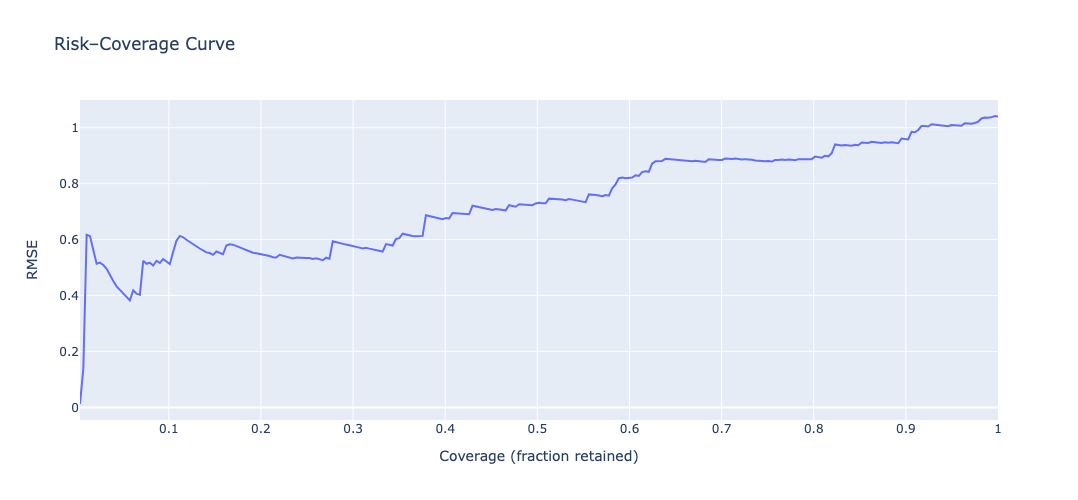

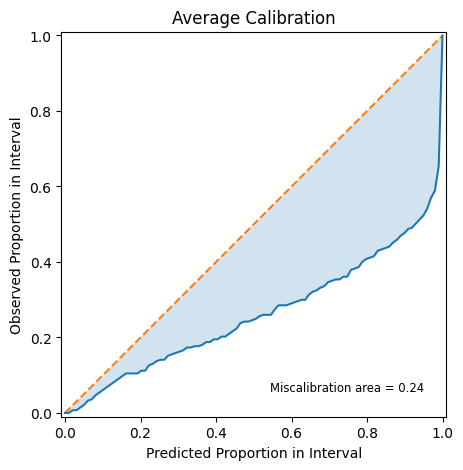

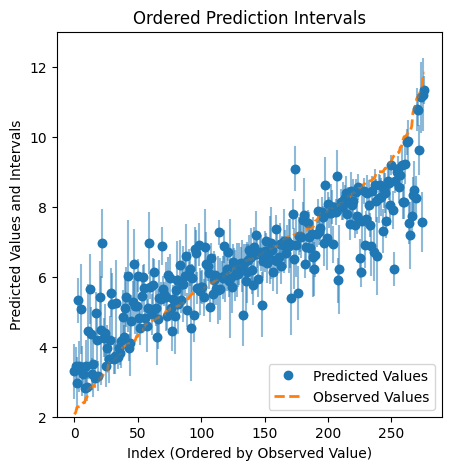

In [36]:
# =========================
# Uncertainty Evaluation Widget
# =========================

# ---- Risk–Coverage AUC ----
def risk_coverage_auc(unc: np.ndarray, residuals: np.ndarray):
    order = np.argsort(unc)  # most confident first
    res_sorted = residuals[order]

    N = len(res_sorted)
    coverage = np.arange(1, N + 1) / N
    risk_curve = np.sqrt(np.cumsum(res_sorted**2) / np.arange(1, N + 1))

    return float(np.trapz(risk_curve, coverage))


# ---- Compute Metrics Per Model ----
def compute_metrics_per_model(df: pl.DataFrame):
    results = []

    for model_name in df["model_name"].unique():

        if model_name == None:
            continue

        df_model = (
            df.filter(pl.col("model_name") == model_name)
              .drop_nulls()
        )

        preds = df_model["preds"].to_numpy()
        targets = df_model["pK"].to_numpy()
        unc = df_model["epistemic_std"].to_numpy()
        residuals = df_model["residual"].to_numpy()

        # Pearson R via Polars
        pearson_r = (
            df_model
            .with_columns(pl.col("residual").abs().alias("abs_res"))
            .select(pl.corr("epistemic_std", "abs_res"))
            .item()
        )

        # Uncertainty Toolbox metrics
        uct_metrics = uct.metrics.get_all_metrics(
            y_pred=preds,
            y_std=unc,
            y_true=targets,
        )

        aurc = risk_coverage_auc(unc, residuals)

        results.append({
            "model_name": model_name,
            "Pearson_R (higher is better)": pearson_r,
            "Negative Log Likelihood (lower is better)": float(uct_metrics["scoring_rule"]["nll"]),
            "Mean-absolute Calibration Error ": float(uct_metrics['avg_calibration']["ma_cal"]),
            "Risk–Coverage AUC (lower is better)": aurc,
        })

    return pl.DataFrame(results).sort("model_name")


# ---- Plot Risk–Coverage ----
def plot_risk_coverage(unc, residuals, label):
    order = np.argsort(unc)
    res_sorted = residuals[order]
    N = len(res_sorted)

    coverage = np.arange(1, N + 1) / N
    rmse_curve = np.sqrt(np.cumsum(res_sorted**2) / np.arange(1, N + 1))

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=coverage, y=rmse_curve, mode="lines", name=label))
    fig.update_layout(
        title="Risk–Coverage Curve",
        xaxis_title="Coverage (fraction retained)",
        yaxis_title="RMSE",
        width=700,
        height=500,
    )
    fig.show()


# =========================
# Usage
# =========================

# ---- Compute metrics table ----
metrics_df = compute_metrics_per_model(df)
print(metrics_df)


# ---- Example: plot for first model ----
model_name = df["model_name"].unique()[0]

print(model_name)

df_model = df.filter(pl.col("model_name") == model_name).drop_nulls()

preds = df_model["preds"].to_numpy()
targets = df_model["pK"].to_numpy()
unc = df_model["epistemic_std"].to_numpy()
residuals = df_model["residual"].to_numpy()

# UCT reliability diagram
uct.plot_calibration(preds, unc, targets)

# UCT coverage plot
uct.plot_intervals_ordered(preds, unc, targets)

# Custom risk–coverage plot
plot_risk_coverage(unc, residuals, label=model_name)

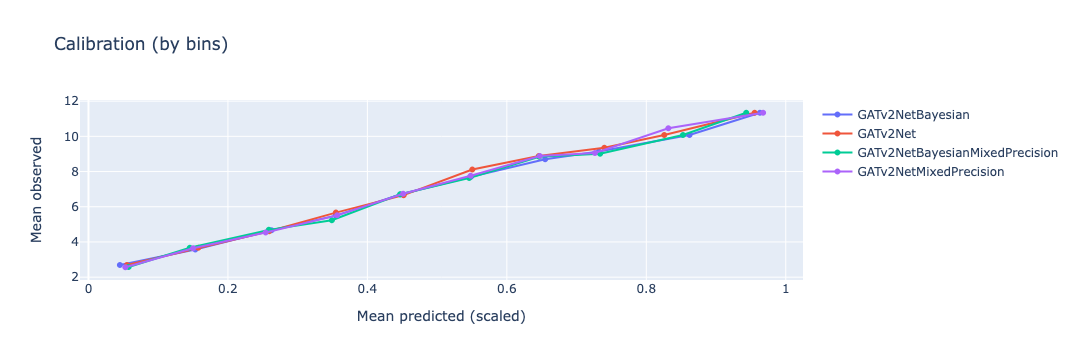

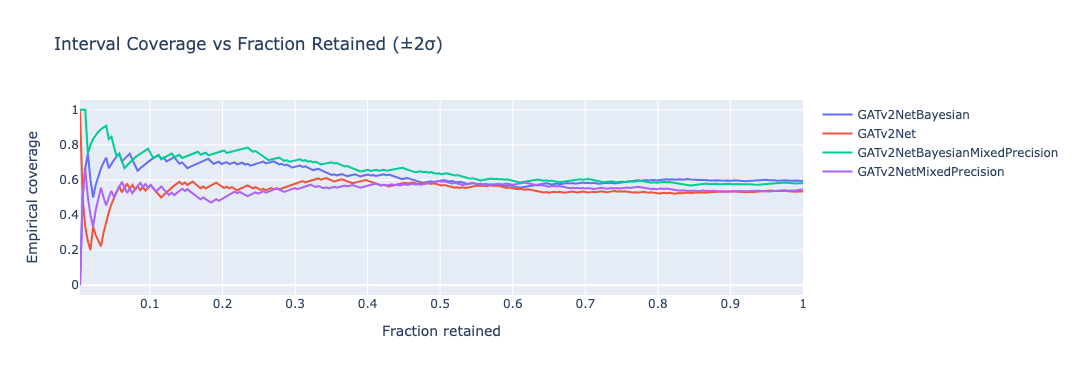

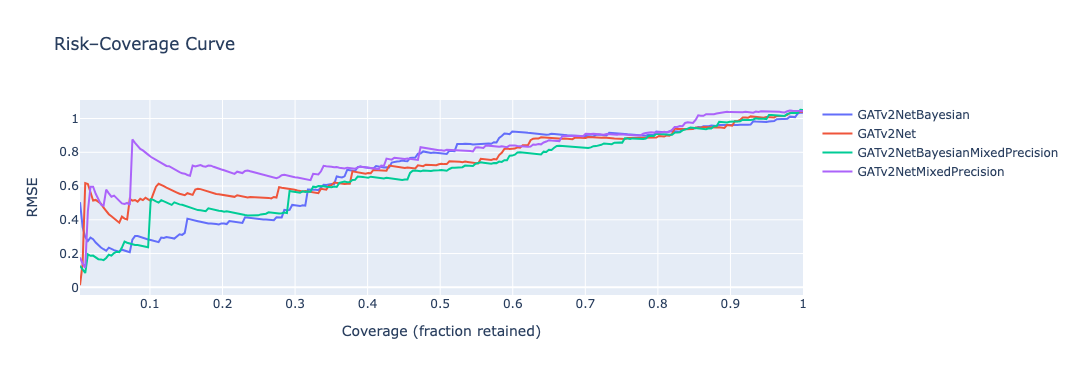

In [41]:
model_names = [m for m in df["model_name"].unique() if m is not None]
fig_cal, fig_int, fig_rc = go.Figure(), go.Figure(), go.Figure()

for m in model_names:
    d = df.filter(pl.col("model_name") == m).drop_nulls()
    preds, y, unc, res = d["preds"].to_numpy(), d["pK"].to_numpy(), d["epistemic_std"].to_numpy(), d["residual"].to_numpy()

    # calibration: bin -> (mean predicted, mean observed)
    bins = np.linspace(0, 1, 11)
    p = (preds - preds.min()) / (preds.max() - preds.min() + 1e-12)  # simple [0,1] scaling
    idx = np.digitize(p, bins) - 1
    x = np.array([p[idx==i].mean() for i in range(10) if (idx==i).any()])
    yb = np.array([y[idx==i].mean() for i in range(10) if (idx==i).any()])
    fig_cal.add_trace(go.Scatter(x=x, y=yb, mode="lines+markers", name=m))

    # intervals: ordered by uncertainty, plot true within ±kσ (k=2) as coverage curve
    order = np.argsort(unc)
    y_s, p_s, u_s = y[order], preds[order], unc[order]
    inside = (y_s >= (p_s - 2*u_s)) & (y_s <= (p_s + 2*u_s))
    fig_int.add_trace(go.Scatter(x=np.arange(1, len(y_s)+1)/len(y_s), y=np.cumsum(inside)/np.arange(1, len(y_s)+1), mode="lines", name=m))

    # risk–coverage
    o = np.argsort(unc); r = res[o]; n = len(r)
    cov = np.arange(1, n+1)/n
    rmse = np.sqrt(np.cumsum(r*r)/np.arange(1, n+1))
    fig_rc.add_trace(go.Scatter(x=cov, y=rmse, mode="lines", name=m))

fig_cal.update_layout(title="Calibration (by bins)", xaxis_title="Mean predicted (scaled)", yaxis_title="Mean observed")
fig_int.update_layout(title="Interval Coverage vs Fraction Retained (±2σ)", xaxis_title="Fraction retained", yaxis_title="Empirical coverage")
fig_rc.update_layout(title="Risk–Coverage Curve", xaxis_title="Coverage (fraction retained)", yaxis_title="RMSE")

fig_cal.show(); fig_int.show(); fig_rc.show()

## §6 Per-Target Kendall τ (Ranking Ability)
Each `unique_id` is treated as its own target.

In [51]:
target_metrics = results.per_target_metrics(
    df.drop_nulls(),
    target_col=UID_COL,
    truth_col=TRUTH_COL,
    pred_col=PRED_COL,
    min_samples=MIN_TARGET_SAMPLES,
)
fig = px.histogram(
    target_metrics.to_dict(as_series=False),
    x="kendall_tau",
    nbins=30,
    title="Per-target Kendall τ distribution",
    labels={"kendall_tau": "Kendall τ"},
)

fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.show()
display(target_metrics.sort("kendall_tau"))

/data/stat-cadd/reub0582/AEV-PLIG-VS/aev_plig/results.py:106: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



target,n,rmse,pearson_r,kendall_tau
str,i64,f64,f64,f64
"""3ao4""",4,1.203632,NaN,NaN
"""3gv9""",4,1.320693,NaN,NaN
"""1uto""",4,0.850555,NaN,NaN
"""1ps3""",4,3.133149,NaN,NaN
"""4ddk""",4,0.966702,NaN,NaN
…,…,…,…,…
"""5dwr""",4,2.126671,NaN,NaN
"""4f2w""",4,0.421809,NaN,NaN
"""2x00""",4,3.712931,NaN,NaN


## §7 Outlier Table

In [31]:
outlier_cols = (
    [UID_COL, TRUTH_COL, PRED_COL, "residual", "epistemic_std"]
    + (["aleatoric_std"] if is_bayesian_output else [])
    + (["model_instance"] if "model_instance" in df.columns else [])
)
outliers = (
    df.select(outlier_cols)
    .drop_nulls()
    .with_columns(pl.col("residual").abs().alias("abs_residual"))
    .sort("abs_residual", descending=True)
    .head(TOP_N_OUTLIERS)
)
display(outliers)

unique_id,pK,preds,residual,epistemic_std,model_instance,abs_residual
str,f64,f32,f64,f32,str,f64
"""2ymd""",3.16,7.185431,4.025431,0.284655,"""GATv2NetMixedPrecision_2026021…",4.025431
"""2ymd""",3.16,6.950386,3.790386,0.494726,"""model_GATv2Net_ligsim90_fep_be…",3.790386
"""2x00""",11.33,7.567757,-3.762243,0.442045,"""GATv2NetMixedPrecision_2026021…",3.762243
"""2x00""",11.33,7.569373,-3.760627,0.426119,"""model_GATv2Net_ligsim90_fep_be…",3.760627
"""2x00""",11.33,7.603014,-3.726986,0.639304,"""GATv2NetBayesianMixedPrecision…",3.726986
…,…,…,…,…,…,…
"""1ps3""",2.28,5.339614,3.059614,0.423144,"""GATv2NetMixedPrecision_2026021…",3.059614
"""3lka""",2.82,5.871807,3.051807,0.454306,"""GATv2NetBayesian_20260212_1731…",3.051807
"""1ps3""",2.28,5.326426,3.046426,0.318841,"""model_GATv2Net_ligsim90_fep_be…",3.046426


## §8 Success Rate

In [32]:
thresholds = pl.Series([0.5, 1.0, 1.5, 2.0])
abs_res    = df.select("residual").drop_nulls()["residual"].abs()
success = pl.DataFrame({
    "Threshold (±pK)": thresholds,
    "N within": thresholds.map_elements(
        lambda t: int((abs_res <= t).sum()), return_dtype=pl.Int64
    ),
    "% within": thresholds.map_elements(
        lambda t: round(100.0 * float((abs_res <= t).mean()), 1), return_dtype=pl.Float64
    ),
})
display(success)

Threshold (±pK),N within,% within
f64,i64,f64
0.5,562,50.7
1.0,816,73.6
1.5,942,85.0
2.0,1022,92.2
